### Скачиваем библиотеку с моделями для работы с текстом

In [3]:
!pip install gensim

  Using cached gensim-4.4.0-cp313-cp313-win_amd64.whl.metadata (8.6 kB)
  Using cached smart_open-7.5.1-py3-none-any.whl.metadata (24 kB)
   ---------------------------------------- 0.0/24.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/24.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/24.4 MB ? eta -:--:--
   ---------------------------------------- 0.3/24.4 MB ? eta -:--:--
    --------------------------------------- 0.5/24.4 MB 884.1 kB/s eta 0:00:28
    --------------------------------------- 0.5/24.4 MB 884.1 kB/s eta 0:00:28
   - -------------------------------------- 0.8/24.4 MB 863.7 kB/s eta 0:00:28
   - -------------------------------------- 1.0/24.4 MB 836.4 kB/s eta 0:00:28
   - -------------------------------------- 1.0/24.4 MB 836.4 kB/s eta 0:00:28
   -- ------------------------------------- 1.3/24.4 MB 814.9 kB/s eta 0:00:29
   -- ------------------------------------- 1.3/24.4 MB 814.9 kB/s eta 0:00:29
   -- -----------------------

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import torch

In [7]:
import gensim.downloader as api

fasttext = api.load('glove-twitter-25')

[==================================================] 100.0% 104.8/104.8MB downloaded


In [8]:
fasttext.most_similar(positive = ['dog'])

[('cat', 0.9590820074081421),
 ('dogs', 0.9244232177734375),
 ('horse', 0.9209402799606323),
 ('monkey', 0.9146843552589417),
 ('pig', 0.9116264581680298),
 ('kid', 0.902455747127533),
 ('puppy', 0.9024086594581604),
 ('bear', 0.9013873934745789),
 ('pet', 0.8971227407455444),
 ('dirty', 0.8893660306930542)]

In [ ]:
fasttext.most_similar(positive = ['king', 'woman'], negative = ['man'])

In [10]:
import re
import string
from collections import Counter

class Vocabulary:
    def __init__(self, texts: list[str], min_freq: 10 = 10):
        text = ' '.join(texts)
        text = re.sub('http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\(\),]|(?:%[0-9a-fA-F]|[0-9a-fA-F]))+', ' ', text)
        text = re.sub('[^a-zA-Z]', ' ', text)

        while '  ' in text:
            text = text.replace('  ', ' ')

        words = text.strip().lower().split()

        c = Counter(words)

        self.vocabulary = list(set([word for word in words if c[word] >= min_freq]))
        self.vocabulary.append('<unk>')
        self._idx2word = {i: word for i, word in enumerate(self.vocabulary)}
        self._word2idx = {word: i for i, word in enumerate(self.vocabulary)}

    def get_vocabulary(self):
        return self.vocabulary

    def idx2rword(self, idx: int):
        if idx not in self._idx2word:
            return '<unk>'
        return self._idx2word[idx]

    def word2idx(self, word: str):
        if word not in self._word2idx:
            return self._word2idx['<unk>']
        return self._word2idx[word]

    # кодируем предложение на входе: каждому слову - свой индекс
    def encode(self, text):
        result = []

        for word in text.split():
            result.append(self.word2idx(word))

        return result

    # для всех слов словаря добавляем вектор из модели, или состоящий из нолей - если в модели такого нет
    def build_vectors(self, fasttext):
        vectors = []
        for word in self.vocabulary:
            if fasttext.has_index_for(word):
                vectors.append(fasttext[word])
            else:
                vectors.append(np.zeros(25))
        return np.stack(vectors)

### Датасет с оценкой тональности отзыва - позитивный или негативный

In [11]:
import pandas as pd

df = pd.read_csv('IMDB Dataset.csv')

df

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


### Создадим кастомный класс датасета

In [13]:
from torch.utils.data import Dataset

class IMDB(Dataset):

    def __init__(self, path):
        self.df = pd.read_csv(path)

        texts = self.df['review'].values

        self.vocab = Vocabulary(texts, min_freq = 5)

        self.label2idx = {'positive' : 0, 'negative' : 1}

    def __getitem__(self, idx):
        text = self.df['review'].loc[idx]
        label = self.label2idx[self.df['sentiment'].loc[idx]]

        # целочисленные индексы слов из словаря
        text = torch.LongTensor(self.vocab.encode(text))
        
        # либо 0, либо 1 - значения вещественные для CrossEntropyLoss
        label = torch.FloatTensor([label])

        return text, label

    def __len__(self):
        return len(self.df)

In [14]:
dataset = IMDB('IMDB Dataset.csv')

In [15]:
dataset[0]

(tensor([39272, 27777, 17144, 14657, 26904, 34342, 30607, 11412,  5239,  4462,
           804, 39272, 39272, 22916, 39272, 32812, 39272, 39272, 36235, 39272,
         17442,  2402,  9151, 22226,  6386, 34042, 24833, 39272, 39272, 39272,
         21949,  6622, 11412, 32909,  9545,  8998, 39272, 35795, 12215, 35041,
         35988, 20327, 38409, 27777, 39272,   123, 38274, 31712, 38464, 18543,
         17144, 10115, 39272, 39272, 39272,  2402,  9151, 39244, 11500, 31269,
         35641, 17144,  1472, 15578,  8355, 39272, 39272, 31269,   300, 21926,
         24331, 24833,  7193, 37192, 39272, 29530,  8355, 39272, 39272,  9151,
         39272, 31712, 17144, 37405,  5942, 27777, 17144, 39272, 39272, 39272,
          9151, 38609, 39272, 17442, 11412,  9151, 17144, 36433, 26528, 37192,
         17144, 39272, 39272, 39272, 39272, 39272, 39272, 19980, 35655, 21104,
         39272, 39272, 34638, 12981, 33485, 27777, 17144, 15239,    31, 14411,
         17144, 36444, 11199, 13444, 37907, 35988, 1

### Разделим выборку на тренировочную и тестовую

In [16]:
from torch.utils.data import random_split

train_dataset, test_dataset = random_split(dataset, (int(len(dataset) * 0.9), len(dataset) - int(len(dataset) * 0.9))) 

### Настроим работу с батчами - collate_fn

In [17]:
# Все предложения - переменной длины, нельзя просто объединить
# Обрабатывать по одному предложению - долго
# Будем вектор каждого предложения приводить к одинаковой длине
from torch.nn.utils.rnn import pad_sequence

pad_idx = len(dataset.vocab.vocabulary)

def collate_fn(batch):
    # pad_sequence - берет тексты из батчей, дополняет до размера максимального вектора значениями padding_value
    # batch_first - размерность [batch_size, max_len], batch_size - размерность векторов
    texts = pad_sequence([b[0] for b in batch], padding_value = pad_idx, batch_first = True)
    labels = torch.stack([b[1] for b in batch])

    return texts, labels

In [18]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size = 64, collate_fn = collate_fn, pin_memory = True)
test_loader = DataLoader(test_dataset, batch_size = 64, collate_fn = collate_fn, pin_memory = True)

In [19]:
b = next(iter(train_loader))

C:\Users\jackt\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [20]:
b

(tensor([[39272, 24760,  2402,  ..., 39273, 39273, 39273],
         [39272, 34876,  5884,  ..., 39273, 39273, 39273],
         [39272,  1791, 32812,  ..., 39273, 39273, 39273],
         ...,
         [39272, 11500, 39272,  ..., 39273, 39273, 39273],
         [39272, 35795, 38487,  ..., 39273, 39273, 39273],
         [39272, 29617,  2402,  ..., 39273, 39273, 39273]]),
 tensor([[1.],
         [1.],
         [0.],
         [1.],
         [0.],
         [1.],
         [0.],
         [0.],
         [0.],
         [1.],
         [1.],
         [0.],
         [1.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [1.],
         [0.],
         [1.],
         [1.],
         [0.],
         [1.],
         [1.],
         [0.],
         [0.],
         [0.],
         [1.],
         [0.],
         [0.],
         [1.],
         [0.],
         [1.],
         [0.],
         [0.],
         [1.],
         [1.],
         [0.],
         [0.],
         [0.],
         [0.],


### Создадим нейронную сеть для классификации текстов

In [33]:
import torch.nn.functional as F
from torch import nn

class TextCNN(nn.Module):
    def __init__(self, vocab_size: int, embedding_dim: int, pad_idx):
        super().__init__()

        # тензор размерности w*n = (vocab_size+1)*25
        # передаем padding_idx - чтобы вектор для него не обучался
        # дообучаем
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx = pad_idx)

        # обучаем
        self.convs = nn.ModuleList(
            [
                nn.Conv2d(
                    in_channels = 1,
                    out_channels = 16,
                    kernel_size = (fs, embedding_dim)
                )
                for fs in [2, 3, 4, 5] # блоки из 2, 3, 4, 5 слов
            ]
        )

        self.fc = nn.Linear(4 * 16, 1)

        self.dropout = nn.Dropout(0.2)

    def forward(self, x):
        x = self.embedding(x)
        x = x.unsqueeze(1)

        # пропускаем через сверточные нейронные сети
        x = [F.relu(conv(x)).squeeze(3) for conv in self.convs]

        # делаем макс пулинг по длине
        x = [F.max_pool1d(_, _.shape[2]).squeeze(2) for _ in x]

        x = self.dropout(torch.cat(x, dim = 1))

        return self.fc(x)

In [34]:
model = TextCNN(vocab_size = len(dataset.vocab.vocabulary) + 1, embedding_dim = 25, pad_idx = pad_idx)

In [35]:
vectors = dataset.vocab.build_vectors(fasttext)

In [36]:
vectors.shape

(39273, 25)

In [37]:
# матрица эмбеддингов - появился паддинг
model.embedding.weight.shape

torch.Size([39274, 25])

In [38]:
# запишем в матрицу предобученные вектора
model.embedding.weight.data[:len(vectors)] = torch.from_numpy(vectors)

In [40]:
# в конце <unk>, паддинг
model.embedding.weight

Parameter containing:
tensor([[-0.6653,  0.4212,  0.1339,  ...,  2.1507, -0.1832, -0.0795],
        [-1.3693,  0.5466,  0.7369,  ...,  0.8343, -0.3474,  0.7856],
        [-2.3310,  0.7709,  0.4433,  ...,  0.4201, -0.4344,  0.4195],
        ...,
        [-1.2155, -0.3896,  0.3858,  ..., -1.0889, -1.1671, -0.0736],
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],
       requires_grad=True)

### Определим функции для обучения

In [41]:
from tqdm import tqdm

def binary_accuracy(preds, y):
    rounded_preds = torch.round(torch.sigmoid(preds))
    correct = (rounded_preds == y).float()
    acc = correct.sum() / len(correct)
    return acc

def train(model) -> float:
    model.train()

    train_loss = 0
    train_accuracy = 0

    for x,y in tqdm(train_loader, desc = 'Train'):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()

        output = model(x)

        loss = loss_fn(output, y)
        train_loss += loss.item()
        train_accuracy += binary_accuracy(output, y)
        
        loss.backward()
        
        optimizer.step()
    train_loss /= len(train_loader)
    train_accuracy /= len(train_loader)

    return train_loss, train_accuracy

In [42]:
@torch.inference_mode()
def evaluate(model):
    model.eval()

    total_loss = 0
    total_accuracy = 0
    for x, y in tqdm(test_loader, desc = 'Evaluate'):
        x, y = x.to(device), y.to(device)

        output = model(x)

        loss = loss_fn(output, y)
        
        total_loss += loss.item()
        total_accuracy += binary_accuracy(output, y)


    total_loss /= len(test_loader)
    total_accuracy /= len(test_loader)
    return total_loss, total_accuracy

In [49]:
from IPython.display import clear_output
def plot_stats(
    train_loss: list[float],
    test_loss: list[float],
    train_accuracy: list[float],
    test_accuracy: list[float],
    title: str
):
    plt.figure(figsize = (16, 10))
    plt.title(title + ' loss')
    plt.plot(train_loss, label = 'Train loss')
    plt.plot(test_loss, label = 'Test loss')
    plt.legend()
    plt.grid()
    plt.show()
    
    plt.figure(figsize = (16, 10))
    plt.title(title + ' accuracy')
    plt.plot(train_accuracy, label = 'Train accuracy')
    plt.plot(test_accuracy, label = 'Test accuracy')
    plt.legend()
    plt.grid()
    plt.show()

In [50]:
def whole_train_value_cycle(
    model,
    num_epochs,
    title
):
    train_loss_history = []
    test_loss_history = []
    train_accuracy_history = []
    test_accuracy_history = []

    for epoch in range(num_epochs):
        train_loss, train_accuracy = train(model)
        test_loss, test_accuracy = evaluate(model)

        train_loss_history.append(train_loss)
        test_loss_history.append(test_loss)
        train_accuracy_history.append(train_accuracy)
        test_accuracy_history.append(test_accuracy)

        clear_output()

        plot_stats(
            train_loss_history,
            test_loss_history,
            train_accuracy_history,
            test_accuracy_history,
            title
        )
        

In [51]:
from torch.optim import Adam

In [52]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

loss_fn = nn.BCEWithLogitsLoss()

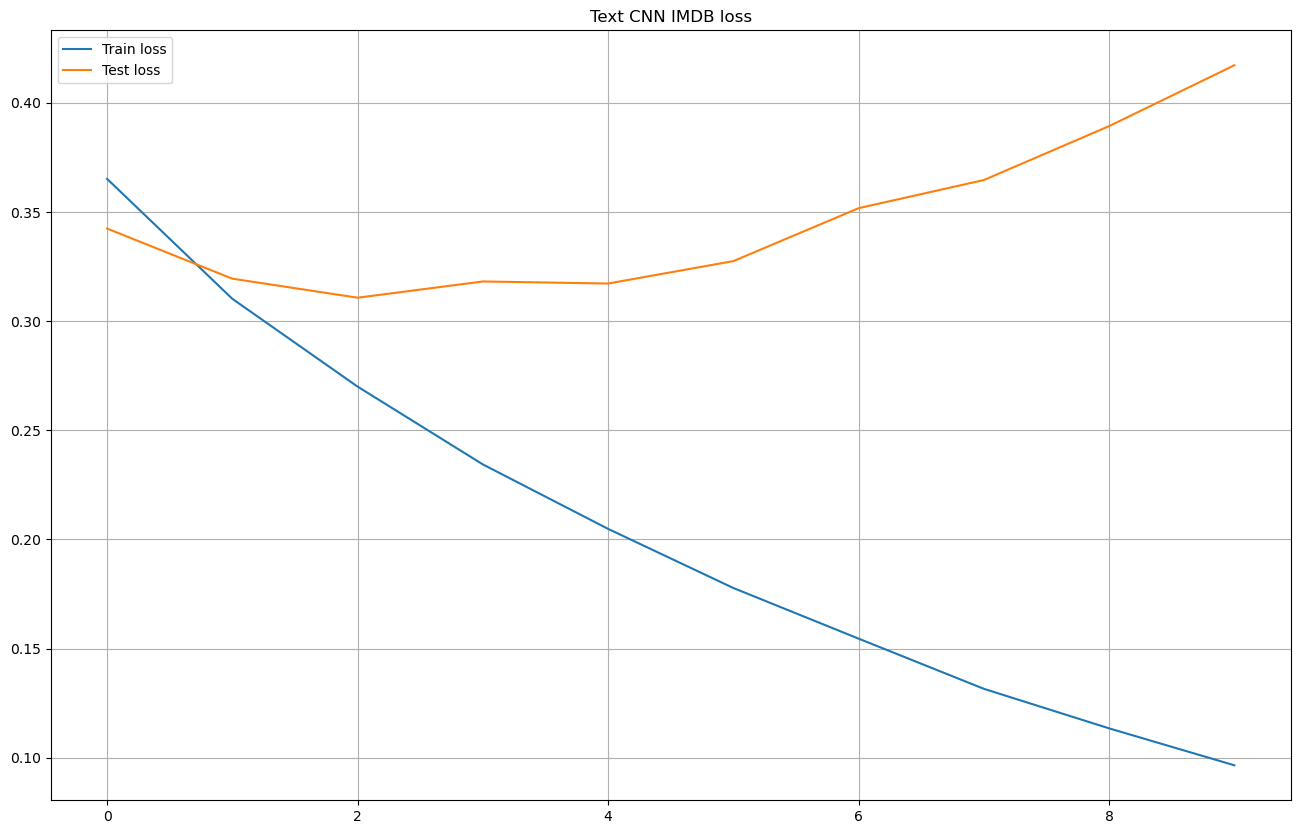

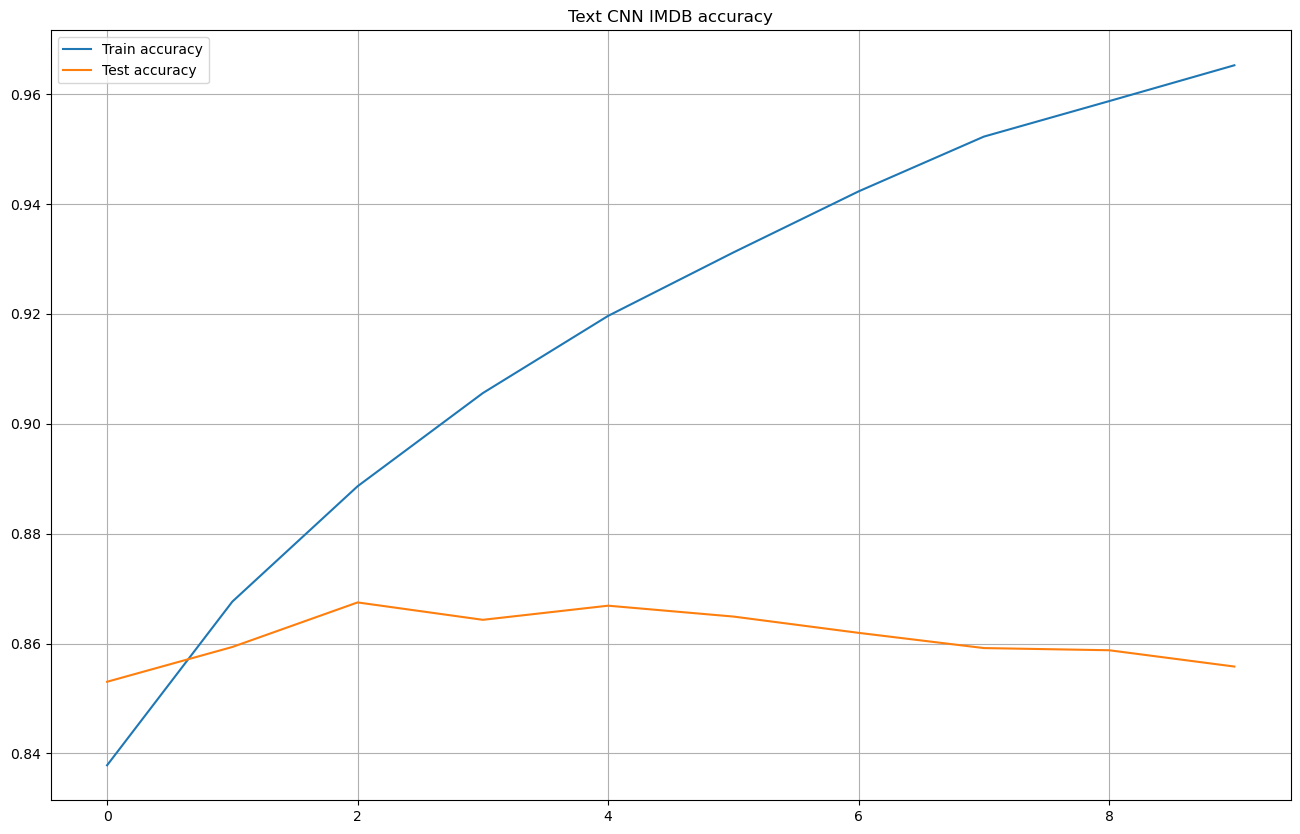

In [53]:
model = model.to(device)

optimizer = Adam(model.parameters(), lr = 1e-3)
whole_train_value_cycle(model, 10, 'Text CNN IMDB')